In [194]:
import pandas as pd
import numpy as np
import re

# Đọc dữ liệu thô thu được sau bước EDA
raw_df = pd.read_csv('../data/raw/02_properties_house_raw.csv')
print(f"Kích thước tập dữ liệu thô ban đầu: {raw_df.shape}")
raw_df.head(5)

Kích thước tập dữ liệu thô ban đầu: (2542, 11)


,title,price_raw,area_raw,address_raw,url,bedrooms,bathrooms,floors,house_direction,legal_status,interior
0,Nhà riêng,5.95,48.0,P. Tân Sơn Nhì (Q. Tân Phú cũ),1,2.0,2.0,2.0,Đông - Nam,Sổ đỏ/ Sổ hồng,Cơ bản
1,Nhà riêng,16.90,90.0,P. Bình Lợi Trung (Q. Bình Thạnh cũ),1,11.0,12.0,3.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ
2,Nhà riêng,8.80,103.0,P. Phước Thắng (TP. Vũng Tàu cũ),1,4.0,5.0,5.0,Tây - Bắc,Sổ đỏ/ Sổ hồng,Không nội thất
3,Nhà riêng,22.00,78.0,P. Tân Sơn Nhất (Q. Tân Bình cũ),1,NaN,NaN,5.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ
4,Nhà riêng,6.80,40.5,P. Phú Thuận (Quận 7 cũ),1,4.0,3.0,3.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ


In [195]:
# Loại bỏ 2 cột định danh văn bản không có giá trị toán học
df = raw_df.drop(columns=['url', 'title'])
print(f"Kích thước sau khi xóa url và title: {df.shape}")
df.head(5)

Kích thước sau khi xóa url và title: (2542, 9)


,price_raw,area_raw,address_raw,bedrooms,bathrooms,floors,house_direction,legal_status,interior
0,5.95,48.0,P. Tân Sơn Nhì (Q. Tân Phú cũ),2.0,2.0,2.0,Đông - Nam,Sổ đỏ/ Sổ hồng,Cơ bản
1,16.90,90.0,P. Bình Lợi Trung (Q. Bình Thạnh cũ),11.0,12.0,3.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ
2,8.80,103.0,P. Phước Thắng (TP. Vũng Tàu cũ),4.0,5.0,5.0,Tây - Bắc,Sổ đỏ/ Sổ hồng,Không nội thất
3,22.00,78.0,P. Tân Sơn Nhất (Q. Tân Bình cũ),NaN,NaN,5.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ
4,6.80,40.5,P. Phú Thuận (Quận 7 cũ),4.0,3.0,3.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ


In [196]:
def extract_district_flexible(address):
    if pd.isna(address):
        return 'Không rõ'
    
    addr_lower = str(address).lower().strip()
    
    # 1. Nhóm Thành phố / Huyện
    if 'thủ đức' in addr_lower: return 'TP. Thủ Đức'
    if 'bình chánh' in addr_lower: return 'Huyện Bình Chánh'
    if 'cần giờ' in addr_lower: return 'Huyện Cần Giờ'
    if 'củ chi' in addr_lower: return 'Huyện Củ Chi'
    if 'hóc môn' in addr_lower: return 'Huyện Hóc Môn'
    if 'nhà bè' in addr_lower: return 'Huyện Nhà Bè'
    
    # 2. Nhóm Các Quận viết bằng Chữ
    if 'bình thạnh' in addr_lower or 'q. bình' in addr_lower: return 'Quận Bình Thạnh'
    if 'bình tân' in addr_lower: return 'Quận Bình Tân'
    if 'gò vấp' in addr_lower or 'q. gò' in addr_lower: return 'Quận Gò Vấp'
    if 'phú nhuận' in addr_lower or 'q. phú' in addr_lower: return 'Quận Phú Nhuận'
    if 'tân bình' in addr_lower: return 'Quận Tân Bình'
    if 'tân phú' in addr_lower: return 'Quận Tân Phú'
    
    # 3. Nhóm Các Quận viết bằng Số (Quận 1 đến Quận 12)
    match_num = re.search(r'(?:quận|q\.?)\s*([0-9]+)', addr_lower)
    if match_num:
        num = int(match_num.group(1))
        if 1 <= num <= 12:
            return f"Quận {num}"
            
    # 4. Fallback phòng hờ cho dữ liệu rác không xác định được
    return 'Khác / Ngoại tỉnh'

# Tiến hành áp dụng hàm đồng bộ của bạn
df['district_clean'] = df['address_raw'].apply(extract_district_flexible)

# Thẳng tay xóa bỏ nhóm 'Khác / Ngoại tỉnh' và 'Không rõ' để sạch dữ liệu 100%
df = df[~df['district_clean'].isin(['Khác / Ngoại tỉnh', 'Không rõ'])].reset_index(drop=True)
df = df.drop(columns=['address_raw'])
print(f" Kích thước sau khi làm sạch địa bàn hành chính: {df.shape}")
df.head(5)

 Kích thước sau khi làm sạch địa bàn hành chính: (2438, 9)


,price_raw,area_raw,bedrooms,bathrooms,floors,house_direction,legal_status,interior,district_clean
0,5.95,48.0,2.0,2.0,2.0,Đông - Nam,Sổ đỏ/ Sổ hồng,Cơ bản,Quận Tân Phú
1,16.90,90.0,11.0,12.0,3.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ,Quận Bình Thạnh
2,22.00,78.0,NaN,NaN,5.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ,Quận Tân Bình
3,6.80,40.5,4.0,3.0,3.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ,Quận 7
4,7.25,36.8,4.0,5.0,5.0,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ,Quận Gò Vấp


In [197]:
def clean_legal(legal):
    if pd.isna(legal):
        return 'Không rõ'
    legal = str(legal).lower().strip()
    
    if any(keyword in legal for keyword in ['sổ hồng', 'sổ đỏ', 'đã có sổ', 'sổ riêng', 'chính chủ', 'hoàn công']):
        return 'Có Sổ'
    elif any(keyword in legal for keyword in ['hợp đồng mua bán', 'hdmb', 'chờ sổ', 'giấy tay', 'đang chờ']):
        return 'Chưa Sổ / HDMB'
    
    return 'Không rõ'

df['legal_clean'] = df['legal_status'].apply(clean_legal)
df = df.drop(columns=['legal_status'])
print(df['legal_clean'].value_counts())
df.head(5)

legal_clean
Có Sổ             2129
Không rõ           302
Chưa Sổ / HDMB       7
Name: count, dtype: int64


,price_raw,area_raw,bedrooms,bathrooms,floors,house_direction,interior,district_clean,legal_clean
0,5.95,48.0,2.0,2.0,2.0,Đông - Nam,Cơ bản,Quận Tân Phú,Có Sổ
1,16.90,90.0,11.0,12.0,3.0,NaN,Đầy đủ,Quận Bình Thạnh,Có Sổ
2,22.00,78.0,NaN,NaN,5.0,NaN,Đầy đủ,Quận Tân Bình,Có Sổ
3,6.80,40.5,4.0,3.0,3.0,NaN,Đầy đủ,Quận 7,Có Sổ
4,7.25,36.8,4.0,5.0,5.0,NaN,Đầy đủ,Quận Gò Vấp,Có Sổ


In [198]:
def extract_interior_clean(interior_text):
    if pd.isna(interior_text):
        return 'Không rõ (NaN)'
    
    int_lower = str(interior_text).lower().strip()
    
    # 1. Nhóm Đầy đủ / Full / Cao cấp
    if any(k in int_lower for k in ['đầy đủ', 'full', 'cao cấp', 'sang xịn', 'để lại nội thất']):
        return 'Đầy đủ nội thất'
        
    # 2. Nhóm Cơ bản
    if 'cơ bản' in int_lower:
        return 'Nội thất cơ bản'
        
    # 3. Nhóm Nhà trống / Không nội thất
    if 'không nội thất' in int_lower or 'nhà trống' in int_lower:
        return 'Không nội thất'
        
    # 4. Nhóm Bàn giao thô
    if 'thô' in int_lower:
        return 'Bàn giao thô'
        
    return 'Khác / Thỏa thuận'

# Áp dụng hàm xử lý nội thất chuẩn của bạn
df['interior_clean'] = df['interior'].apply(extract_interior_clean)
df = df.drop(columns=['interior'])
print(df['interior_clean'].value_counts())
df.head(5)

interior_clean
Không rõ (NaN)       1091
Đầy đủ nội thất       883
Nội thất cơ bản       374
Không nội thất         72
Khác / Thỏa thuận      14
Bàn giao thô            4
Name: count, dtype: int64


,price_raw,area_raw,bedrooms,bathrooms,floors,house_direction,district_clean,legal_clean,interior_clean
0,5.95,48.0,2.0,2.0,2.0,Đông - Nam,Quận Tân Phú,Có Sổ,Nội thất cơ bản
1,16.90,90.0,11.0,12.0,3.0,NaN,Quận Bình Thạnh,Có Sổ,Đầy đủ nội thất
2,22.00,78.0,NaN,NaN,5.0,NaN,Quận Tân Bình,Có Sổ,Đầy đủ nội thất
3,6.80,40.5,4.0,3.0,3.0,NaN,Quận 7,Có Sổ,Đầy đủ nội thất
4,7.25,36.8,4.0,5.0,5.0,NaN,Quận Gò Vấp,Có Sổ,Đầy đủ nội thất


In [199]:
def clean_direction(direction):
    if pd.isna(direction):
        return 'Không rõ'
    direction = str(direction).lower().replace('-', ' ').strip()
    
    valid_directions = ['đông nam', 'đông bắc', 'tây nam', 'tây bắc', 'đông', 'tây', 'nam', 'bắc']
    for d in valid_directions:
        if d in " ".join(direction.split()):
            return d.title()
    return 'Không rõ'

df['direction_clean'] = df['house_direction'].apply(clean_direction)
df = df.drop(columns=['house_direction'])
print(df['direction_clean'].value_counts())

df.head(10)

direction_clean
Không rõ    2003
Đông Nam      82
Tây Nam       63
Tây           54
Nam           52
Đông          49
Bắc           46
Tây Bắc       45
Đông Bắc      44
Name: count, dtype: int64


,price_raw,area_raw,bedrooms,bathrooms,floors,district_clean,legal_clean,interior_clean,direction_clean
0,5.95,48.0,2.0,2.0,2.0,Quận Tân Phú,Có Sổ,Nội thất cơ bản,Đông Nam
1,16.90,90.0,11.0,12.0,3.0,Quận Bình Thạnh,Có Sổ,Đầy đủ nội thất,Không rõ
2,22.00,78.0,NaN,NaN,5.0,Quận Tân Bình,Có Sổ,Đầy đủ nội thất,Không rõ
3,6.80,40.5,4.0,3.0,3.0,Quận 7,Có Sổ,Đầy đủ nội thất,Không rõ
4,7.25,36.8,4.0,5.0,5.0,Quận Gò Vấp,Có Sổ,Đầy đủ nội thất,Không rõ
5,25.00,98.0,NaN,NaN,NaN,Quận 3,Có Sổ,Không rõ (NaN),Không rõ
6,5.95,71.5,3.0,2.0,2.0,TP. Thủ Đức,Có Sổ,Nội thất cơ bản,Tây Bắc
7,12.00,39.9,8.0,NaN,NaN,Quận Phú Nhuận,Có Sổ,Đầy đủ nội thất,Không rõ
8,62.68,255.3,5.0,5.0,4.0,Quận Phú Nhuận,Có Sổ,Không rõ (NaN),Tây Nam
9,18.55,76.0,2.0,2.0,2.0,Quận Bình Thạnh,Có Sổ,Nội thất cơ bản,Nam


In [200]:
# Điền khuyết bằng Median cho phòng ngủ/phòng tắm, điền Mode (1 tầng) cho số tầng
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['floors'] = df['floors'].fillna(1)

# Ép bộ lọc vật lý giới hạn số lượng phòng từ 1 đến 15 phòng
df = df[(df['bedrooms'] >= 1) & (df['bedrooms'] <= 15)]
df = df[(df['bathrooms'] >= 1) & (df['bathrooms'] <= 15)]
df = df[(df['floors'] >= 1) & (df['floors'] <= 15)]

df = df.reset_index(drop=True)
print(f" Kích thước sau khi lọc sạch vật lý hệ thống phòng: {df.shape}")
df.head(6)

 Kích thước sau khi lọc sạch vật lý hệ thống phòng: (2398, 9)


,price_raw,area_raw,bedrooms,bathrooms,floors,district_clean,legal_clean,interior_clean,direction_clean
0,5.95,48.0,2.0,2.0,2.0,Quận Tân Phú,Có Sổ,Nội thất cơ bản,Đông Nam
1,16.90,90.0,11.0,12.0,3.0,Quận Bình Thạnh,Có Sổ,Đầy đủ nội thất,Không rõ
2,22.00,78.0,4.0,4.0,5.0,Quận Tân Bình,Có Sổ,Đầy đủ nội thất,Không rõ
3,6.80,40.5,4.0,3.0,3.0,Quận 7,Có Sổ,Đầy đủ nội thất,Không rõ
4,7.25,36.8,4.0,5.0,5.0,Quận Gò Vấp,Có Sổ,Đầy đủ nội thất,Không rõ
5,25.00,98.0,4.0,4.0,1.0,Quận 3,Có Sổ,Không rõ (NaN),Không rõ


In [201]:
# Tạo đặc trưng tổng số phòng để gom nhóm thông tin trước khi đẩy qua kiểm toán ma trận VIF
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df.head(2)

,price_raw,area_raw,bedrooms,bathrooms,floors,district_clean,legal_clean,interior_clean,direction_clean,total_rooms
0,5.95,48.0,2.0,2.0,2.0,Quận Tân Phú,Có Sổ,Nội thất cơ bản,Đông Nam,4.0
1,16.90,90.0,11.0,12.0,3.0,Quận Bình Thạnh,Có Sổ,Đầy đủ nội thất,Không rõ,23.0


In [202]:
# Tính toán đơn giá tạm thời phục vụ lọc Outlier chính xác
df['price_per_m2'] = df['price_raw'] / df['area_raw']

# Lọc Diện tích logic: Từ 10m2 đến 600m2
df = df[(df['area_raw'] >= 10) & (df['area_raw'] <= 600)]

# Lọc Đơn giá và Giá tổng: Chặn trên 1 tỷ/m2, giá tổng 400 tỷ và loại bỏ giá âm/bằng 0
df = df[(df['price_per_m2'] <= 1.0) & (df['price_raw'] <= 400.0) & (df['price_raw'] > 0)]

# Loại bỏ cột đơn giá tạm thời để tránh rò rỉ đặc trưng (Data Leakage)
df = df.drop(columns=['price_per_m2'])

df = df.reset_index(drop=True)
print(f"Kích thước tập dữ liệu sau khi lọc Outlier thực tế: {df.shape}")

Kích thước tập dữ liệu sau khi lọc Outlier thực tế: (2369, 10)


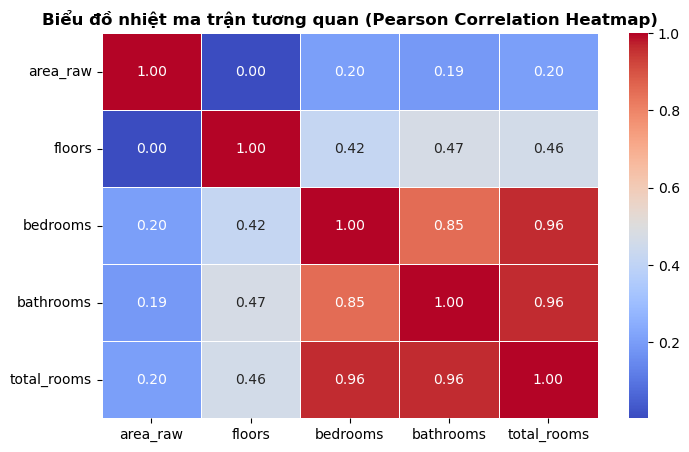


BẮT ĐẦU CHẠY THUẬT TOÁN VÒNG LẶP VIF TỰ ĐỘNG...


 Thuật toán tự động Drop biến trùng lặp thông tin: 'bedrooms' (VIF = inf)
 Thuật toán tự động Drop biến trùng lặp thông tin: 'total_rooms' (VIF = 79.13)


 KẾT QUẢ NGHIỆM THU: Ma trận đạt trạng thái an toàn tuyệt đối (VIF < 10)!
Đặc trưng (Features)  Chỉ số VIF
            area_raw    2.455320
              floors    5.355732
           bathrooms    6.358385


d:\C\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [203]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_features = ['area_raw', 'floors', 'bedrooms', 'bathrooms', 'total_rooms']
corr_matrix = df[num_features].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Biểu đồ nhiệt ma trận tương quan (Pearson Correlation Heatmap)', fontsize=12, fontweight='bold')
plt.show()

print("\nBẮT ĐẦU CHẠY THUẬT TOÁN VÒNG LẶP VIF TỰ ĐỘNG...")
print("\n")

while True:
    X_vif = df[num_features].dropna()
    
    vif_data = pd.DataFrame()
    vif_data["Đặc trưng (Features)"] = X_vif.columns
    vif_data["Chỉ số VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    
    max_vif = vif_data['Chỉ số VIF'].max()
    
    if max_vif > 10 or np.isinf(max_vif):
        max_vif_feature = vif_data.loc[vif_data['Chỉ số VIF'] == max_vif, 'Đặc trưng (Features)'].values[0]
        print(f" Thuật toán tự động Drop biến trùng lặp thông tin: '{max_vif_feature}' (VIF = {max_vif:.2f})")
        
        num_features.remove(max_vif_feature)
        df = df.drop(columns=[max_vif_feature])
    else:
        print("\n")
        print(" KẾT QUẢ NGHIỆM THU: Ma trận đạt trạng thái an toàn tuyệt đối (VIF < 10)!")
        print(vif_data.to_string(index=False))
        break

df = df.reset_index(drop=True)

In [204]:
# 1. Mã hóa Ordinal cho 22 Địa bàn chuẩn theo thứ tự tăng dần trung vị giá từ EDA của bạn
district_mapping = {
    'Huyện Cần Giờ': 0, 'Huyện Củ Chi': 1, 'Huyện Hóc Môn': 2, 'Huyện Nhà Bè': 3, 'Huyện Bình Chánh': 4,
    'Quận 6': 5, 'Quận 4': 6, 'Quận 11': 7, 'Quận 5': 8, 'Quận 8': 9, 'Quận 9': 10, 'Quận 3': 11,
    'Quận 10': 12, 'Quận 2': 13, 'Quận Tân Phú': 14, 'Quận Tân Bình': 15, 'Quận Phú Nhuận': 16,
    'Quận Gò Vấp': 17, 'Quận Bình Thạnh': 18, 'Quận 12': 19, 'Quận 7': 20, 'TP. Thủ Đức': 21, 'Quận 1': 22
}
df['address_encoded'] = df['district_clean'].map(district_mapping)

# 2. Mã hóa Ordinal cho Nội thất dựa theo đúng thứ tự nhãn hàm sạch của bạn
interior_mapping = {
    'Khác / Thỏa thuận': 0, 'Nội thất cơ bản': 1, 'Không nội thất': 2, 'Không rõ (NaN)': 3, 'Đầy đủ nội thất': 4, 'Bàn giao thô': 5
}
df['interior_encoded'] = df['interior_clean'].map(interior_mapping)

# 3. Mã hóa Ordinal cho Pháp lý theo độ an toàn
legal_mapping = {
    'Không rõ': 0, 'Chưa Sổ / HDMB': 1, 'Có Sổ': 2
}
df['legal_encoded'] = df['legal_clean'].map(legal_mapping)

# 4. Mã hóa One-Hot Encoding cho cột Hướng nhà
df_dir = pd.get_dummies(df['direction_clean'], prefix='dir', dtype=int)
if 'dir_Không rõ' in df_dir.columns:
    df_dir = df_dir.drop(columns=['dir_Không rõ'])

df = pd.concat([df, df_dir], axis=1)
df = df.drop(columns=['district_clean', 'interior_clean', 'legal_clean', 'direction_clean'])
df.head(11)

,price_raw,area_raw,bathrooms,floors,address_encoded,interior_encoded,legal_encoded,dir_Bắc,dir_Nam,dir_Tây,dir_Tây Bắc,dir_Tây Nam,dir_Đông,dir_Đông Bắc,dir_Đông Nam
0,5.95,48.0,2.0,2.0,14,1,2,0,0,0,0,0,0,0,1
1,16.90,90.0,12.0,3.0,18,4,2,0,0,0,0,0,0,0,0
2,22.00,78.0,4.0,5.0,15,4,2,0,0,0,0,0,0,0,0
3,6.80,40.5,3.0,3.0,20,4,2,0,0,0,0,0,0,0,0
4,7.25,36.8,5.0,5.0,17,4,2,0,0,0,0,0,0,0,0
5,25.00,98.0,4.0,1.0,11,3,2,0,0,0,0,0,0,0,0
6,5.95,71.5,2.0,2.0,21,1,2,0,0,0,1,0,0,0,0
7,12.00,39.9,4.0,1.0,16,4,2,0,0,0,0,0,0,0,0
8,62.68,255.3,5.0,4.0,16,3,2,0,0,0,0,1,0,0,0
9,18.55,76.0,2.0,2.0,18,1,2,0,1,0,0,0,0,0,0


In [205]:
print(" KIỂM TRA ĐẦU RA MA TRẬN DỮ LIỆU SẠCH:")
print(f"- Kiểu dữ liệu các cột hiện tại:\n{df.dtypes}\n")
print(f"- Kiểm tra ô trống còn sót lại (NaN): {df.isna().sum().sum()}")
print(f"- Kích thước ma trận cuối cùng: {df.shape}")

# Xuất ma trận sạch ra file .csv sẵn sàng để nạp vào huấn luyện model từ scratch
df.to_csv('../data/processed/clean_data.csv', index=False)
print("\n XUẤT FILE CLEAN_DATA.CSV THÀNH CÔNG!")
df.head(5)

 KIỂM TRA ĐẦU RA MA TRẬN DỮ LIỆU SẠCH:
- Kiểu dữ liệu các cột hiện tại:
price_raw           float64
area_raw            float64
bathrooms           float64
floors              float64
address_encoded       int64
interior_encoded      int64
legal_encoded         int64
dir_Bắc               int64
dir_Nam               int64
dir_Tây               int64
dir_Tây Bắc           int64
dir_Tây Nam           int64
dir_Đông              int64
dir_Đông Bắc          int64
dir_Đông Nam          int64
dtype: object

- Kiểm tra ô trống còn sót lại (NaN): 0
- Kích thước ma trận cuối cùng: (2369, 15)

 XUẤT FILE CLEAN_DATA.CSV THÀNH CÔNG!


,price_raw,area_raw,bathrooms,floors,address_encoded,interior_encoded,legal_encoded,dir_Bắc,dir_Nam,dir_Tây,dir_Tây Bắc,dir_Tây Nam,dir_Đông,dir_Đông Bắc,dir_Đông Nam
0,5.95,48.0,2.0,2.0,14,1,2,0,0,0,0,0,0,0,1
1,16.90,90.0,12.0,3.0,18,4,2,0,0,0,0,0,0,0,0
2,22.00,78.0,4.0,5.0,15,4,2,0,0,0,0,0,0,0,0
3,6.80,40.5,3.0,3.0,20,4,2,0,0,0,0,0,0,0,0
4,7.25,36.8,5.0,5.0,17,4,2,0,0,0,0,0,0,0,0


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2369 entries, 0 to 2368
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_raw         2369 non-null   float64
 1   area_raw          2369 non-null   float64
 2   bathrooms         2369 non-null   float64
 3   floors            2369 non-null   float64
 4   address_encoded   2369 non-null   int64  
 5   interior_encoded  2369 non-null   int64  
 6   legal_encoded     2369 non-null   int64  
 7   dir_Bắc           2369 non-null   int64  
 8   dir_Nam           2369 non-null   int64  
 9   dir_Tây           2369 non-null   int64  
 10  dir_Tây Bắc       2369 non-null   int64  
 11  dir_Tây Nam       2369 non-null   int64  
 12  dir_Đông          2369 non-null   int64  
 13  dir_Đông Bắc      2369 non-null   int64  
 14  dir_Đông Nam      2369 non-null   int64  
dtypes: float64(4), int64(11)
memory usage: 277.7 KB


In [207]:
df.describe()

,price_raw,area_raw,bathrooms,floors,address_encoded,interior_encoded,legal_encoded,dir_Bắc,dir_Nam,dir_Tây,dir_Tây Bắc,dir_Tây Nam,dir_Đông,dir_Đông Bắc,dir_Đông Nam
count,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000
mean,14.720279,82.830004,4.064162,3.019840,15.447446,3.003377,1.745462,0.018995,0.021950,0.022372,0.018573,0.026171,0.019840,0.017729,0.033347
std,19.348173,63.109568,1.926023,1.473308,5.112572,1.035675,0.664468,0.136537,0.146552,0.147922,0.135041,0.159678,0.139478,0.131993,0.179580
min,0.980000,12.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,49.000000,3.000000,2.000000,13.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.800000,66.800000,4.000000,3.000000,17.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.000000,95.000000,5.000000,4.000000,19.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,300.000000,593.000000,15.000000,9.000000,22.000000,5.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
